Papers:

"Habitable Zones Around Main Sequence Stars"

"A New Definition of Exoplanet Habitability"

Trying to graph isochrones.

**Packages, Definitions, and Functions**

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import pathlib
import scipy
from scipy import constants as const
from astropy import constants as astroconst
from scipy.integrate import quad

mass01 = "/content/0001000M.track.eep"

def load_mist(filepath):
  colnames = None
#snip data
  with open(filepath, 'r') as f:
    for line in f:
      if line.startswith('#') and 'star_age' in line:
        colnames = line[1:].split()
        break
  if colnames is None:
    raise ValueError("No column header line")
#read data
  df = pd.read_csv(
      filepath,
      comment='#',
      delim_whitespace=True,
      names = colnames
  )
  return df

# Constants used in HBZ flux boundaries
seff = [0,0,0,0,0,0]
seffsun  = [1.776,1.107, 0.356, 0.320, 1.188, 0.99]
a = [2.136e-4, 1.332e-4, 6.171e-5, 5.547e-5, 1.433e-4, 1.209e-4]  # K^-1
b = [2.533e-8, 1.580e-8, 1.698e-9, 1.526e-9, 1.707e-8, 1.404e-8]  # K^-2
e = [-1.332e-11, -8.308e-12, -3.198e-12, -2.874e-12, -8.968e-12, -7.418e-12]  #K^-3
d = [-3.097e-15, -1.931e-15, -5.575e-16, -5.011e-16, -2.084e-15, -1.713e-15]  #K^-4

# Constants
c = (float) (3e8)
h = const.h
kB = const.k
N_A = const.Avogadro
# P(I) constants from Hall et al. (2023)
alpha = 1.0e-5
beta = 1.0e-3
gamma = 2.0

# R_rate values (respiration rates in micromol O2 mg^-1 hr^-1)
# From paper: Rrate ranges from 0.3Pmax (optimistic) to 0.6Pmax and 0.8Pmax (pessimistic)
r1 = 0.3/(beta + 2*(alpha*gamma)**0.5)
r2 = 0.6/(beta + 2*(alpha*gamma)**0.5)
r3 = 0.8/(beta + 2*(alpha*gamma)**0.5)
R_rate_values = [r1, r2, r3]

Pmax_labels = ['Excellent: R_rate= 0.3 Pmax', 'Optimistic: R_rate= 0.6 Pmax', 'Pessimistic: R_rate=0.8 Pmax']

# f_a values (atmospheric attenuation)
f_a_values = [1.0, 0.6, 0.2]
f_a_labels = ['No attenuation: f_a=1.0', 'Moderate: f_a=0.6', 'Earth-like: f_a=0.2']




def calc_N_dot_star(T_star, R_star):

    lambda_min = 400e-9  # 400 nm in METERS
    lambda_max = 700e-9  # 700 nm

    def integrand(lambda_m):
        # Planck function integrated over wavelength
        exponent = (h * c) / (lambda_m * kB * T_star)
        # Avoid overflow in exponential
        if exponent > 700:
            return 0
        try:
            planck = (2 * c) / (lambda_m**4) * (1 / (np.exp(exponent) - 1))
            return planck
        except Exception as e:
            print(f"Error in integrand: {e}")
            return 0 # Return 0 for any exceptions during planck calculation


    try:
        # we only need the integral value
        integral, _ = quad(integrand, lambda_min, lambda_max, limit=100)
        # Equation (9): N_dot = 4π^2R^2 \int B_lambda dlambda
        N_dot = 4 * np.pi**2 * R_star**2 * integral
        if np.isnan(N_dot) or not np.isfinite(N_dot): # Ensuring valid data for N star dot
             return np.nan
        return N_dot
    except Exception as e:
        print(f"Error in quad integration: {e} for T_star={T_star}. Returning NaN.")
        return np.nan # Return NaN if quad integration fails



def I_crit(R_rate):
  # Coefficients of the I quadratic:
 # A = 10**6 * (R_rate/3600) * alpha      # changed from hr^-1 to s^-1 and from mg^-1 to kg^-1
  #B = 10**6 * (R_rate/3600) * beta - 1.0
  #C = 10**6 * (R_rate/3600) * gamma
  A = R_rate * alpha      # changed from hr^-1 to s^-1 and from mg^-1 to kg^-1
  B = R_rate * beta - 1.0
  C = R_rate * gamma


  # ensuring only real values
  discriminant = (B**2) - (4 * A * C)
  if discriminant < 0:
    return np.nan, np.nan # Return two NaN values for unpacking

  I_inner = (-B + (discriminant)**(1/2)) / (2 * A)
  I_outer = (-B - (discriminant)**(1/2)) / (2 * A)

  return I_inner, I_outer




N_A = const.Avogadro
def pz_distance_calc(Ndot_val, I_crit_val, f_a_val):
  AU_m = const.au
  a = np.sqrt(f_a_val * Ndot_val * 1e6 / (4.0 * np.pi * I_crit_val * N_A))
  a_AU = a / AU_m
  return a_AU




# Now finding all a's
R_sun_m = 6.957*10**8  #m
def pz_distance(df):
  out = df.copy()

  T_eff = out["Teff"].to_numpy()
  R_star_m = 10**out["log_R"].to_numpy() * R_sun_m

  N_dot_array = []
  for T, R in zip(T_eff, R_star_m):
    N_dot_array.append(calc_N_dot_star(T, R))
  N_dot_array = np.array(N_dot_array)
  out["Ndot"] = N_dot_array

  for f_a_loop_val in f_a_values:
    for R_rate_loop_val in R_rate_values:
      I_inner, I_outer = I_crit(R_rate_loop_val)
      label = f"fa{f_a_loop_val}_Rr{R_rate_loop_val}"

      if np.isnan(I_inner) or np.isnan(I_outer):
        out[f"PHZ_inner_{label}"] = np.nan
        out[f"PHZ_outer_{label}"] = np.nan

      else:
        out[f"PHZ_inner_{label}"] = pz_distance_calc(N_dot_array, I_inner, f_a_loop_val)
        out[f"PHZ_outer_{label}"] = pz_distance_calc(N_dot_array, I_outer, f_a_loop_val)

  return out

**Importing the data**

In [39]:
df_01 = load_mist(mass01)

df_01.head()
df_01.columns
df_01[['star_age', 'log_L', 'log_Teff']].head()

# un logging
df_01['L'] = 10**(df_01['log_L'])
df_01['Teff'] = 10**(df_01['log_Teff'])

write_path = '/content/0001000M.track.eep'
df_01.to_csv(write_path, sep=',', index=False)
# HZ Coefficients from Kopparapu
hz_labels = [
    "Recent Venus",        # 0
    "Runaway Greenhouse",  # 1  <-- conservative inner
    "Maximum Greenhouse",  # 2  <-- conservative outer
    "Early Mars",          # 3  <-- optimistic outer
    "5ME Runaway",         # 4
    "0.1ME Runaway"        # 5
]

# Getting T*
Tstar = df_01['Teff'].to_numpy() - 5780.0

# Finding S effectives
for i, label in enumerate(hz_labels):
    seff_i = seffsun[i] + a[i]*Tstar + b[i]*Tstar**2 + e[i]*Tstar**3 + d[i]*Tstar**4
    seff_i = np.where(seff_i > 0, seff_i, np.nan)
    col_seff = f"S_eff_{label.replace(' ','_')}"
    col_dist = f"d_AU_{label.replace(' ','_')}"
    df_01[col_seff] = seff_i
    df_01[col_dist] = np.sqrt(df_01['L'].to_numpy() / seff_i )

/tmp/ipykernel_8920/497312818.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


**Plotting Habitable Zone**

/tmp/ipykernel_8920/4063309481.py:23: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 1e10)


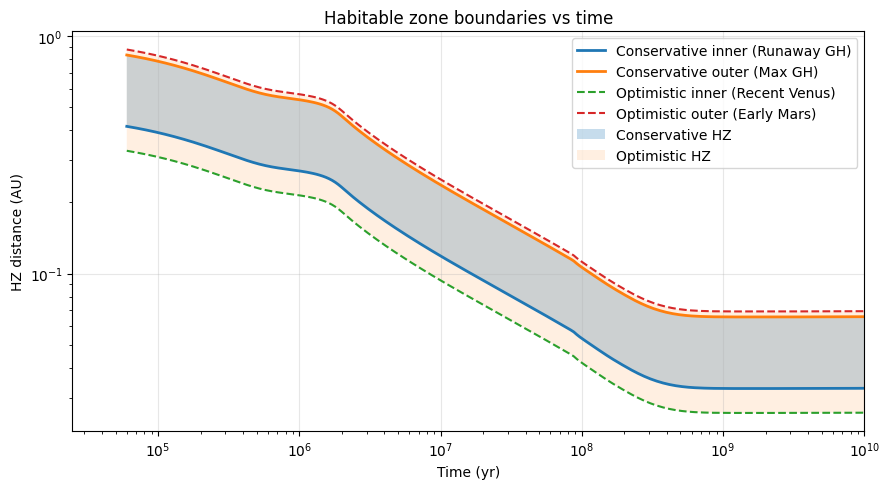

In [40]:
# conservative and optimistic boundaries:
# conservative inner = Runaway Greenhouse (index 1)
# conservative outer = Maximum Greenhouse (index 2)
# optimistic inner = Recent Venus (index 0)
# optimistic outer = Early Mars (index 3)

t = df_01['star_age']

plt.figure(figsize=(9,5))

plt.semilogx(t, df_01['d_AU_Runaway_Greenhouse'], lw=2, label='Conservative inner (Runaway GH)')
plt.semilogx(t, df_01['d_AU_Maximum_Greenhouse'], lw=2, label='Conservative outer (Max GH)')
plt.semilogx(t, df_01['d_AU_Recent_Venus'], lw=1.5, ls='--', label='Optimistic inner (Recent Venus)')
plt.semilogx(t, df_01['d_AU_Early_Mars'], lw=1.5, ls='--', label='Optimistic outer (Early Mars)')


plt.fill_between(t, df_01['d_AU_Runaway_Greenhouse'], df_01['d_AU_Maximum_Greenhouse'],
                 alpha=0.25, label='Conservative HZ')
plt.fill_between(t, df_01['d_AU_Recent_Venus'], df_01['d_AU_Early_Mars'],
                 alpha=0.12, label='Optimistic HZ')

plt.xlabel('Time (yr)')
plt.xlim(0, 1e10)
plt.ylabel('HZ distance (AU)')
plt.yscale('log')
plt.title('Habitable zone boundaries vs time')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print(R_rate_values)
for R_rate, label in zip(R_rate_values, Pmax_labels):
    I_out, I_in = I_crit(R_rate)
    print(f"{label} (R_rate={R_rate}):  I_outer = {I_out:.1f},  I_inner = {I_in:.1f}")

[30.16812117721199, 60.33624235442398, 80.44832313923197]
Excellent: R_rate= 0.3 Pmax (R_rate=30.16812117721199):  I_outer = 3151.3,  I_inner = 63.5
Optimistic: R_rate= 0.6 Pmax (R_rate=60.33624235442398):  I_outer = 1416.2,  I_inner = 141.2
Pessimistic: R_rate=0.8 Pmax (R_rate=80.44832313923197):  I_outer = 927.4,  I_inner = 215.7


**Plotting PHZ**

<>:47: SyntaxWarning: invalid escape sequence '\,'
<>:57: SyntaxWarning: invalid escape sequence '\o'
<>:47: SyntaxWarning: invalid escape sequence '\,'
<>:57: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_8920/3818640120.py:47: SyntaxWarning: invalid escape sequence '\,'
  ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
/tmp/ipykernel_8920/3818640120.py:57: SyntaxWarning: invalid escape sequence '\o'
  fig.suptitle("Photosynthetic Habitable Zone — 0.1 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)


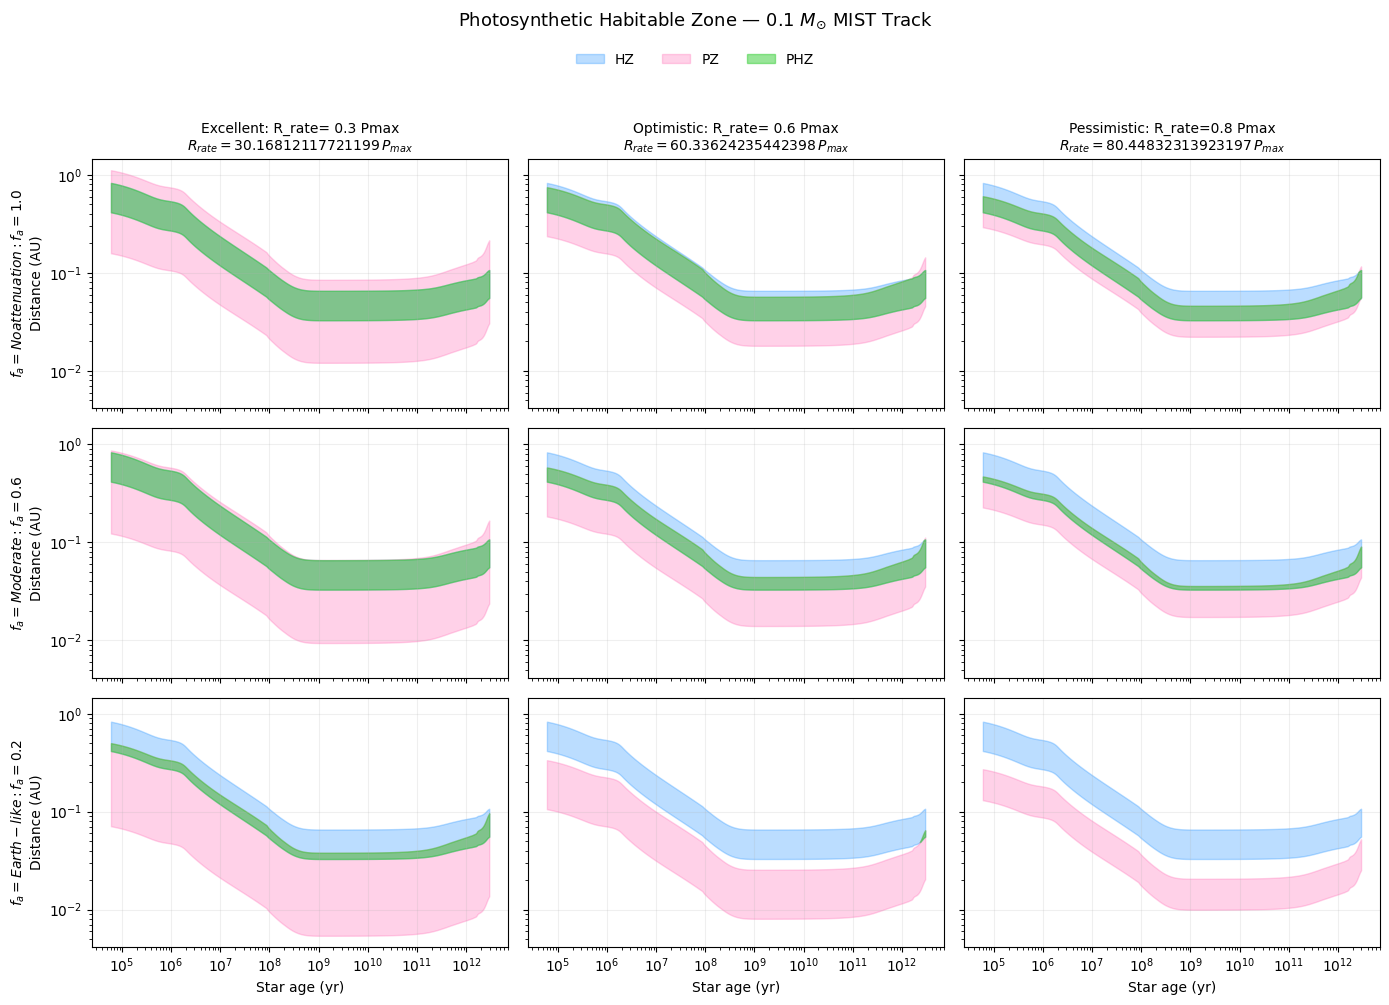

         star_age  star_mass     star_mdot  he_core_mass  c_core_mass  \
0    6.008835e+04   0.100000 -9.983650e-14           0.0          0.0   
1    6.328472e+04   0.100000 -9.824912e-14           0.0          0.0   
2    6.665106e+04   0.100000 -9.662922e-14           0.0          0.0   
3    7.019447e+04   0.100000 -9.497381e-14           0.0          0.0   
4    7.392253e+04   0.100000 -9.328252e-14           0.0          0.0   
..            ...        ...           ...           ...          ...   
449  2.920670e+12   0.099688 -1.588118e-16           0.0          0.0   
450  2.928611e+12   0.099687 -1.589126e-16           0.0          0.0   
451  2.936570e+12   0.099685 -1.590067e-16           0.0          0.0   
452  2.944542e+12   0.099684 -1.590893e-16           0.0          0.0   
453  2.952142e+12   0.099683 -1.591618e-16           0.0          0.0   

     o_core_mass     log_L  log_L_div_Ledd    log_LH    log_LHe  ...  \
0            0.0 -0.797748       -4.153912 -4.04786

In [48]:
df_plot = pz_distance(df_01)
t = df_plot['star_age'].to_numpy()

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)
for row in range(len(f_a_values)): # Iterate using index to get both value and label
    current_f_a_value = f_a_values[row]
    current_f_a_label = f_a_labels[row]

    for col, (R_rate, rlabel) in enumerate(zip(R_rate_values, Pmax_labels)):
        ax = axes[row, col]
        # Construct tag using numerical value for f_a to match DataFrame column names
        tag = f"fa{current_f_a_value}_Rr{R_rate}"

        #  HZ boundaries (conservative: Runaway GH inner, Max GH outer)
        hz_in  = df_plot["d_AU_Runaway_Greenhouse"].to_numpy()
        hz_out = df_plot["d_AU_Maximum_Greenhouse"].to_numpy()

        #  PZ boundaries
        pz_in  = df_plot[f"PHZ_inner_{tag}"].to_numpy()
        pz_out = df_plot[f"PHZ_outer_{tag}"].to_numpy()

        #  Overlap , inner occurs at the zone with the furthest inner zone, and outer at the zone with the smallest outer zone.
        phz_in  = np.maximum(hz_in, pz_in)
        phz_out = np.minimum(hz_out, pz_out)
        # Only valid where inner < outer
        overlap_mask = phz_in < phz_out

        # Masks for finite values
        m = np.isfinite(t) & np.isfinite(hz_in) & np.isfinite(hz_out)
        mp = np.isfinite(t) & np.isfinite(pz_in) & np.isfinite(pz_out)

        # Plot fills
        ax.fill_between(t[m],  hz_in[m],  hz_out[m],  color="dodgerblue", alpha=0.3, label="HZ")
        ax.fill_between(t[mp], pz_in[mp], pz_out[mp], color="hotpink",    alpha=0.3, label="PZ")

        # PHZ overlap
        mo = m & mp & overlap_mask
        if mo.any():
            ax.fill_between(t[mo], phz_in[mo], phz_out[mo], color="limegreen", alpha=0.5, label="PHZ")

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(alpha=0.2)

        # Labels on edges only
        if row == 0:
            ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
        if row == 2:
            ax.set_xlabel("Star age (yr)")
        if col == 0:
            # Use the descriptive label for the ylabel
            ax.set_ylabel(f"$f_a = {current_f_a_label}$\nDistance (AU)", fontsize=10)
# Grab legend from one panel
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.97), ncol=3, frameon=False)

fig.suptitle("Photosynthetic Habitable Zone — 0.1 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print(df_plot)